In [1]:
import warnings
warnings.filterwarnings('ignore')
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
 
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

In [2]:
# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

In [2]:
# =============================================================================
# PHASE 0 — DATABASE CONNECTION
# =============================================================================
 
DB_USER     = "root"
DB_PASSWORD = "Your Password"     
DB_HOST     = "localhost"
DB_PORT     = "3306"
DB_NAME     = "your database name"         # database name


engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True
)
 
print("=" * 60)
print("PHASE 0 — Connecting to MySQL")
print("=" * 60)

NameError: name 'create_engine' is not defined

In [4]:
# Quick sanity check — row counts
sanity_query = """
    SELECT 'msme_profiles'    AS tbl, COUNT(*) AS row_count FROM msme_profiles
    UNION ALL
    SELECT 'loan_records',             COUNT(*) FROM loan_records
    UNION ALL
    SELECT 'txn_logs',                 COUNT(*) FROM txn_logs
    UNION ALL
    SELECT 'repayment_history',        COUNT(*) FROM repayment_history
"""
df_sanity = pd.read_sql(sanity_query, engine)
print("\nRow counts per table:")
print(df_sanity.to_string(index=False))


Row counts per table:
              tbl  row_count
    msme_profiles      50000
     loan_records      50000
         txn_logs     120000
repayment_history      50000


In [4]:
from sqlalchemy import text
# =============================================================================
# PHASE 1 — PULL DATA FROM MySQL VIEW
# =============================================================================
 
print("\n" + "=" * 60)
print("PHASE 1 — Pulling v_credit_master from MySQL")
print("=" * 60)
 
# If the view doesn't exist yet, create it first
create_view_sql = """
CREATE OR REPLACE VIEW v_credit_master AS
SELECT
    m.msme_id,
    m.business_name,
    m.category,
    m.state,
    m.business_age_yrs,
    m.annual_turnover,
    m.gst_registered,
    m.employee_count,
    l.loan_id,
    l.loan_amount,
    l.disbursement_dt,
    l.tenure_days,
    l.interest_rate,
    l.loan_status,
    l.delinquency_flag,
    ROUND(AVG(t.monthly_txn_vol), 2)    AS avg_monthly_vol,
    ROUND(STDDEV(t.monthly_txn_vol), 2) AS txn_volatility,
    COUNT(t.txn_month)                  AS active_months,
    SUM(t.txn_count)                    AS total_txns,
    ROUND(AVG(IFNULL(r.days_overdue, 0)), 2) AS avg_days_overdue,
    ROUND(
        SUM(r.amount_paid) / NULLIF(SUM(r.amount_due), 0)
    , 4)                                AS repayment_ratio,
    COUNT(CASE WHEN r.days_overdue > 30  THEN 1 END) AS late_30d,
    COUNT(CASE WHEN r.days_overdue > 90  THEN 1 END) AS late_90d,
    COUNT(CASE WHEN r.paid_date IS NULL  THEN 1 END) AS unpaid_emis
FROM msme_profiles m
LEFT JOIN loan_records     l ON m.msme_id = l.msme_id
LEFT JOIN txn_logs          t ON m.msme_id = t.msme_id
LEFT JOIN repayment_history r ON l.loan_id  = r.loan_id
GROUP BY
    m.msme_id, m.business_name, m.category, m.state,
    m.business_age_yrs, m.annual_turnover,
    m.gst_registered, m.employee_count,
    l.loan_id, l.loan_amount, l.disbursement_dt,
    l.tenure_days, l.interest_rate,
    l.loan_status, l.delinquency_flag
"""
 
with engine.connect() as conn:
    conn.execute(text(create_view_sql)) if hasattr(conn, 'execute') else None
 
# Pull everything into a DataFrame
df = pd.read_sql("SELECT * FROM v_credit_master", engine)
 
print(f"\nDataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("\nColumn dtypes:\n", df.dtypes.to_string())


PHASE 1 — Pulling v_credit_master from MySQL

Dataset shape  : 50,000 rows × 24 columns
Memory usage   : 26.4 MB

Column dtypes:
 msme_id              object
business_name        object
category             object
state                object
business_age_yrs    float64
annual_turnover     float64
gst_registered        int64
employee_count        int64
loan_id              object
loan_amount         float64
disbursement_dt      object
tenure_days           int64
interest_rate       float64
loan_status          object
delinquency_flag      int64
avg_monthly_vol     float64
txn_volatility      float64
active_months         int64
total_txns          float64
avg_days_overdue    float64
repayment_ratio     float64
late_30d              int64
late_90d              int64
unpaid_emis           int64


<h3>Data Cleaning</h3>

In [5]:
print("\n" + "=" * 60)
print("PHASE 2 — Data Cleaning")
print("=" * 60)
 
df_clean = df.copy()

# ── 2.1 Missing value audit ───────────────────────────────────────────────────
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0]
print("\nMissing values:")
print(missing_report.to_string() if len(missing_report) else "  None found — all columns complete.")
 
# ── 2.2 Fix data types ────────────────────────────────────────────────────────
df_clean['disbursement_dt'] = pd.to_datetime(df_clean['disbursement_dt'], errors='coerce')
df_clean['delinquency_flag'] = df_clean['delinquency_flag'].astype(int)
df_clean['gst_registered']   = df_clean['gst_registered'].astype(int)
 
# ── 2.3 Fill NULLs with sensible defaults ─────────────────────────────────────
fill_zero_cols = [
    'avg_monthly_vol', 'txn_volatility', 'active_months',
    'total_txns', 'avg_days_overdue', 'late_30d', 'late_90d', 'unpaid_emis'
]
df_clean[fill_zero_cols] = df_clean[fill_zero_cols].fillna(0)

# repayment_ratio: NULL means no repayments recorded → treat as 0
df_clean['repayment_ratio'] = df_clean['repayment_ratio'].fillna(0)
 
print(f"\nNulls after cleaning: {df_clean.isnull().sum().sum()}")


PHASE 2 — Data Cleaning

Missing values:
                 missing_count  missing_pct
avg_monthly_vol          40000         80.0
txn_volatility           40000         80.0
total_txns               40000         80.0

Nulls after cleaning: 0


In [6]:
# ── 2.4 Duplicate detection ───────────────────────────────────────────────────
dupes = df_clean.duplicated(subset=['msme_id', 'loan_id']).sum()
print(f"Duplicate msme_id+loan_id pairs: {dupes}")
if dupes > 0:
    df_clean = df_clean.drop_duplicates(subset=['msme_id', 'loan_id'], keep='first')
    print(f"  Removed. Clean shape: {df_clean.shape}")

Duplicate msme_id+loan_id pairs: 0


In [7]:
# ── 2.5 Outlier capping — winsorize at 1st and 99th percentile ───────────────
# Preserves all rows; just clips extreme values
winsorise_cols = [
    'avg_monthly_vol', 'txn_volatility', 'loan_amount',
    'annual_turnover', 'avg_days_overdue', 'repayment_ratio'
]
 
def winsorise(series, lo=0.01, hi=0.99):
    lower = series.quantile(lo)
    upper = series.quantile(hi)
    return series.clip(lower, upper)
 
for col in winsorise_cols:
    df_clean[col] = winsorise(df_clean[col])
 
print(f"\nWinsorisation applied to: {winsorise_cols}")


Winsorisation applied to: ['avg_monthly_vol', 'txn_volatility', 'loan_amount', 'annual_turnover', 'avg_days_overdue', 'repayment_ratio']


In [8]:
# ── 2.6 Log-transform skewed monetary columns ─────────────────────────────────
# Log1p handles zeros safely (log(0) is undefined, log1p(0) = 0)
df_clean['log_monthly_vol']  = np.log1p(df_clean['avg_monthly_vol'])
df_clean['log_loan_amount']  = np.log1p(df_clean['loan_amount'])
df_clean['log_turnover']     = np.log1p(df_clean['annual_turnover'])
df_clean['log_txn_vol_std']  = np.log1p(df_clean['txn_volatility'])
 
print("Log-transform applied to: monthly_vol, loan_amount, turnover, volatility")

Log-transform applied to: monthly_vol, loan_amount, turnover, volatility


In [9]:
# ── 2.7 Derived cleaning columns ──────────────────────────────────────────────
# NPA candidate: unpaid past 90 days and loan not yet marked NPA
df_clean['is_npa_candidate'] = (
    (df_clean['avg_days_overdue'] > 90) &
    (df_clean['loan_status'] != 'NPA')
).astype(int)
 
# Loan-to-turnover ratio — overleveraged flag
df_clean['loan_to_turnover'] = (
    df_clean['loan_amount'] /
    df_clean['annual_turnover'].replace(0, np.nan)
).fillna(0)
 
print(f"\nFinal clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Default rate (target balance): {df_clean['delinquency_flag'].mean()*100:.2f}%")
 


Final clean dataset: 50,000 rows × 30 columns
Default rate (target balance): 11.81%


<h3>EXPLORATORY DATA ANALYSIS (EDA)</h3>


PHASE 3 — Exploratory Data Analysis

Default rate by sector:
       category  total  defaults  default_rate      avg_loan
        Textile   7239      1478     20.417185 291906.273887
   Construction   7226      1325     18.336562 288854.009482
Food Processing   7084       948     13.382270 289866.277741
         Retail   7118       846     11.885361 277667.512942
           FMCG   7076       604      8.535896 281145.201191
         Pharma   7142       427      5.978717 291984.091319
    IT Services   7115       275      3.865074 283652.216754


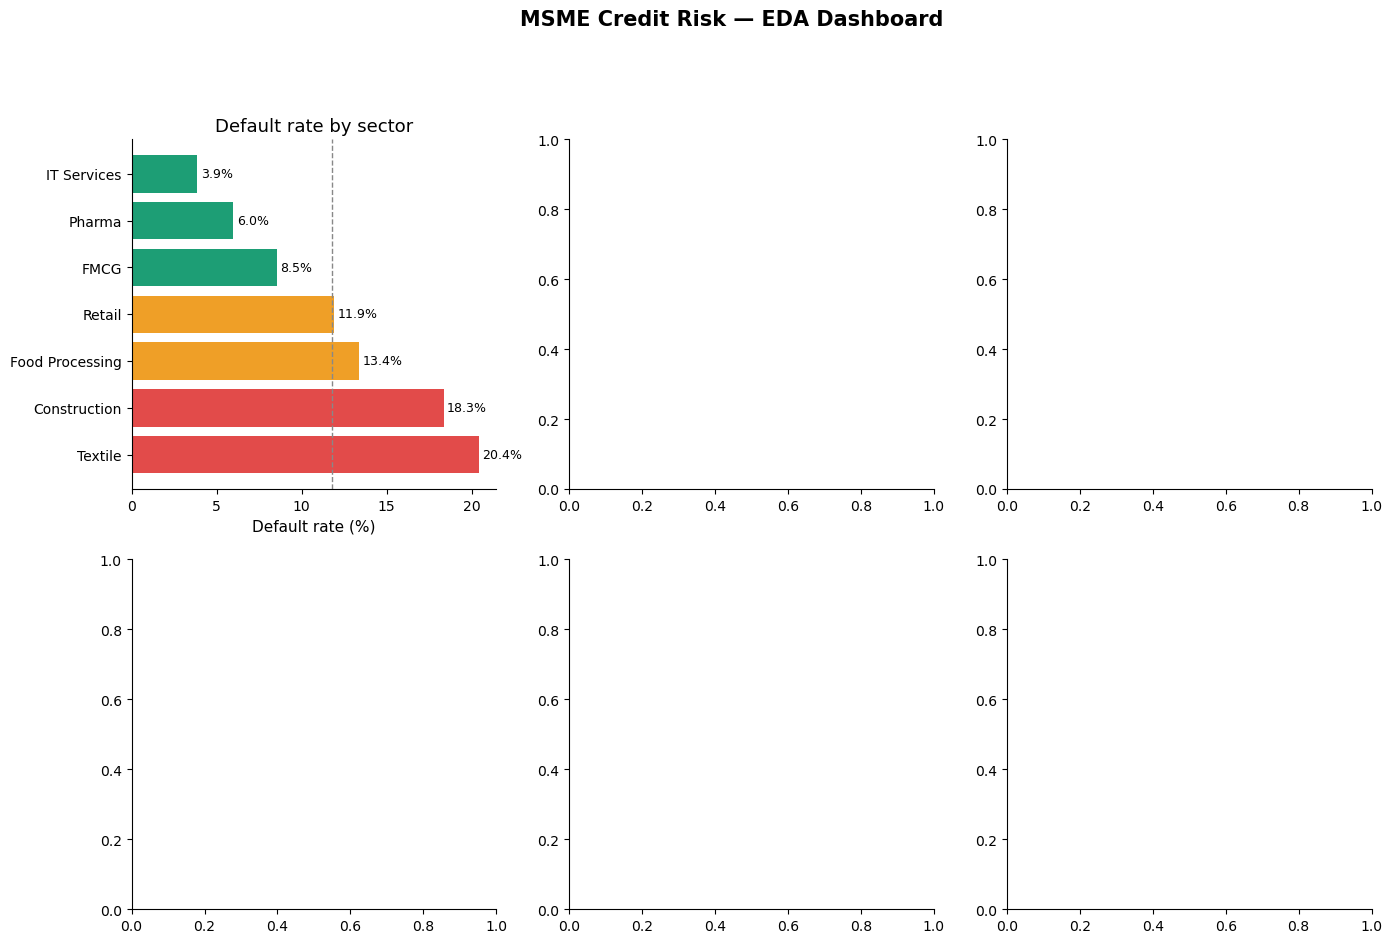

In [26]:
print("\n" + "=" * 60)
print("PHASE 3 — Exploratory Data Analysis")
print("=" * 60)
 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('MSME Credit Risk — EDA Dashboard', fontsize=15, fontweight='bold', y=1.01)

# ── 3.1 Default rate by sector ───────────────────────────────────────────────
sector_stats = (
    df_clean.groupby('category')
    .agg(
        total      = ('loan_id',         'count'),
        defaults   = ('delinquency_flag', 'sum'),
        avg_loan   = ('loan_amount',      'mean'),
        avg_repay  = ('repayment_ratio',  'mean'),
    )
    .assign(default_rate=lambda x: x['defaults'] / x['total'] * 100)
    .sort_values('default_rate', ascending=False)
    .reset_index()
)
print("\nDefault rate by sector:")
print(sector_stats[['category','total','defaults','default_rate','avg_loan']].to_string(index=False))
 
colors = ['#E24B4A' if r > 15 else '#EF9F27' if r > 10 else '#1D9E75'
          for r in sector_stats['default_rate']]
axes[0,0].barh(sector_stats['category'], sector_stats['default_rate'], color=colors)
axes[0,0].axvline(sector_stats['default_rate'].mean(), color='#888', linestyle='--', linewidth=1)
axes[0,0].set_xlabel('Default rate (%)')
axes[0,0].set_title('Default rate by sector')
for i, v in enumerate(sector_stats['default_rate']):
    axes[0,0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

In [14]:
# ── 3.3 Transaction volatility vs default ────────────────────────────────────
df_clean['vol_quartile'] = pd.qcut(
    df_clean['txn_volatility'],
    q=4,
    duplicates='drop'
)
vol_stats = (
    df_clean.groupby('vol_quartile', observed=True)['delinquency_flag']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'delinquency_flag': 'default_rate'})
)
axes[0,2].bar(vol_stats['vol_quartile'].astype(str), vol_stats['default_rate'],
              color=['#1D9E75','#EF9F27','#D85A30','#E24B4A'])
axes[0,2].set_xlabel('Txn volatility quartile')
axes[0,2].set_ylabel('Default rate (%)')
axes[0,2].set_title('Volatility quartile vs default rate')
print("\nDefault rate by txn volatility quartile:")
print(vol_stats.to_string(index=False))


Default rate by txn volatility quartile:
      vol_quartile  default_rate
(-0.001, 71926.59]        11.806


In [15]:
# ── 3.4 Loan amount distribution by default status ───────────────────────────
df_clean[df_clean['delinquency_flag']==0]['log_loan_amount'].plot(
    kind='hist', bins=40, ax=axes[1,0], alpha=0.6, color='#1D9E75', label='Repaid')
df_clean[df_clean['delinquency_flag']==1]['log_loan_amount'].plot(
    kind='hist', bins=40, ax=axes[1,0], alpha=0.6, color='#E24B4A', label='Default')
axes[1,0].set_xlabel('Log loan amount')
axes[1,0].set_title('Loan amount distribution (log scale)')
axes[1,0].legend()

In [16]:
# ── 3.5 Repayment ratio distribution ─────────────────────────────────────────
axes[1,1].boxplot(
    [
        df_clean[df_clean['delinquency_flag']==0]['repayment_ratio'].dropna(),
        df_clean[df_clean['delinquency_flag']==1]['repayment_ratio'].dropna()
    ],
    labels=['Repaid', 'Default'],
    patch_artist=True,
    boxprops=dict(facecolor='#E6F1FB'),
    medianprops=dict(color='#185FA5', linewidth=2)
)
axes[1,1].set_ylabel('Repayment ratio')
axes[1,1].set_title('Repayment ratio vs default status')

Text(0.5, 1.0, 'Repayment ratio vs default status')

In [17]:
# ── 3.6 Correlation heatmap ───────────────────────────────────────────────────
numeric_cols = [
    'log_monthly_vol', 'log_txn_vol_std', 'log_loan_amount',
    'repayment_ratio', 'avg_days_overdue', 'late_30d',
    'business_age_yrs', 'loan_to_turnover', 'delinquency_flag'
]
corr = df_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=axes[1,2],
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, cbar_kws={'shrink': 0.7}
)
axes[1,2].set_title('Feature correlation matrix')
axes[1,2].tick_params(axis='x', rotation=45, labelsize=7)
axes[1,2].tick_params(axis='y', labelsize=7)
 
plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nEDA dashboard saved → eda_dashboard.png")

<Figure size 640x480 with 0 Axes>


EDA dashboard saved → eda_dashboard.png


In [18]:
# Key EDA finding — print the top default signals
print("\n--- TOP 3 DEFAULT SIGNALS FOUND ---")
corr_with_target = corr['delinquency_flag'].drop('delinquency_flag').abs().sort_values(ascending=False)
print(corr_with_target.to_string())


--- TOP 3 DEFAULT SIGNALS FOUND ---
avg_days_overdue    0.737541
late_30d            0.148239
business_age_yrs    0.004739
repayment_ratio     0.003516
loan_to_turnover    0.002059
log_loan_amount     0.001306
log_txn_vol_std     0.000493
log_monthly_vol     0.000466


<h3>FEATURE ENGINEERING & RISK SCORE</h3>

In [19]:
print("\n" + "=" * 60)
print("PHASE 4 — Feature Engineering & Composite Risk Score")
print("=" * 60)
 
df_feat = df_clean.copy()

# ── 4.1 Normalize sub-scores to [0, 100] ─────────────────────────────────────
def normalize_to_100(series):
    """Min-max scale to [0, 100]. Higher = riskier."""
    rng = series.max() - series.min()
    if rng == 0:
        return pd.Series(50, index=series.index)
    return (series - series.min()) / rng * 100
 
# Feature 1: Repayment Risk (weight 35%)
# Lower repayment ratio → higher risk
df_feat['repay_risk'] = normalize_to_100(1 - df_feat['repayment_ratio'])
 
# Feature 2: Transaction Volatility Score (weight 25%)
# Higher volatility → higher risk
df_feat['vol_score'] = normalize_to_100(df_feat['txn_volatility'])
 
# Feature 3: Delinquency Rate Score (weight 20%)
# More late payments → higher risk
df_feat['delinq_score'] = normalize_to_100(df_feat['late_30d'])
 
# Feature 4: Business Stability Score (weight 15%)
# Newer business → higher risk (inverse of age)
df_feat['stability_score'] = normalize_to_100(
    1 / (df_feat['business_age_yrs'] + 0.5)
)

# Feature 5: Sector Risk Score (weight 5%)
# Based on empirical default rates from EDA
SECTOR_RISK = {
    'IT Services':      4,
    'Pharma':           6,
    'FMCG':             9,
    'Retail':          12,
    'Food Processing': 14,
    'Construction':    18,
    'Textile':         21,
}
df_feat['sector_score'] = (
    df_feat['category']
    .map(SECTOR_RISK)
    .fillna(12)   # default for unknown sectors
)


PHASE 4 — Feature Engineering & Composite Risk Score


In [20]:
# ── 4.2 Composite Risk Score ──────────────────────────────────────────────────
df_feat['risk_score'] = (
    0.35 * df_feat['repay_risk']    +
    0.25 * df_feat['vol_score']     +
    0.20 * df_feat['delinq_score']  +
    0.15 * df_feat['stability_score'] +
    0.05 * df_feat['sector_score']
)
# ── 4.3 Risk Tier Classification ──────────────────────────────────────────────
df_feat['risk_tier'] = pd.cut(
    df_feat['risk_score'],
    bins=[0, 30, 60, 100],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)
 
tier_dist = df_feat['risk_tier'].value_counts().sort_index()
print("\nRisk tier distribution:")
for tier, count in tier_dist.items():
    pct = count / len(df_feat) * 100
    print(f"  {tier:8s}: {count:6,}  ({pct:.1f}%)")


Risk tier distribution:
  Low     : 37,461  (74.9%)
  Medium  : 12,483  (25.0%)
  High    :     56  (0.1%)


In [21]:
# ── 4.4 Credit Policy Decision Engine ─────────────────────────────────────────
def credit_decision(row):
    """
    Rule-based credit policy — runs before the ML model.
    Returns: AUTO_REJECT | MANUAL_REVIEW | AUTO_APPROVE
    """
    # Hard rejects
    if row['risk_score']       > 75:    return 'AUTO_REJECT'
    if row['repayment_ratio']  < 0.70:  return 'AUTO_REJECT'
    if row['late_30d']         >= 3:    return 'AUTO_REJECT'
    if row['is_npa_candidate'] == 1:    return 'AUTO_REJECT'
    if row['loan_status']      == 'NPA':return 'AUTO_REJECT'
 
    # Manual review triggers
    if row['risk_score']        > 45:   return 'MANUAL_REVIEW'
    if row['business_age_yrs']  < 1.5:  return 'MANUAL_REVIEW'
    if row['loan_amount']       > 2_500_000:  return 'MANUAL_REVIEW'
    if (row['txn_volatility'] > row['avg_monthly_vol'] * 0.6
            and row['avg_monthly_vol'] > 0):  return 'MANUAL_REVIEW'
 
    return 'AUTO_APPROVE'
 
df_feat['decision'] = df_feat.apply(credit_decision, axis=1)
 
decision_dist = df_feat['decision'].value_counts()
print("\nCredit policy decision distribution:")
for dec, count in decision_dist.items():
    pct = count / len(df_feat) * 100
    print(f"  {dec:15s}: {count:6,}  ({pct:.1f}%)")


Credit policy decision distribution:
  AUTO_APPROVE   : 25,826  (51.7%)
  AUTO_REJECT    : 23,593  (47.2%)
  MANUAL_REVIEW  :    581  (1.2%)


<h3>LOGISTIC REGRESSION MODEL</h3>


PHASE 5 — Logistic Regression Model

Feature matrix : 50,000 rows × 13 features
Target balance : 11.81% positive (defaults)

Train : 37,500 rows
Test  : 12,500 rows

Model trained.

5-Fold CV AUC : 0.9719 ± 0.0043
Per-fold      : [np.float64(0.9725), np.float64(0.9717), np.float64(0.964), np.float64(0.9768), np.float64(0.9745)]

TEST SET RESULTS
AUC-ROC        : 0.9759

Classification report (threshold = 0.35):
              precision    recall  f1-score   support

      Repaid       0.99      1.00      1.00     11024
     Default       1.00      0.93      0.97      1476

    accuracy                           0.99     12500
   macro avg       1.00      0.97      0.98     12500
weighted avg       0.99      0.99      0.99     12500


Feature importance (logistic regression coefficients):
         feature  coefficient
avg_days_overdue    22.533733
    delinq_score    -3.805187
    sector_score     0.528181
       vol_score     0.172932
 log_monthly_vol    -0.108657
loan_to_turnover    -

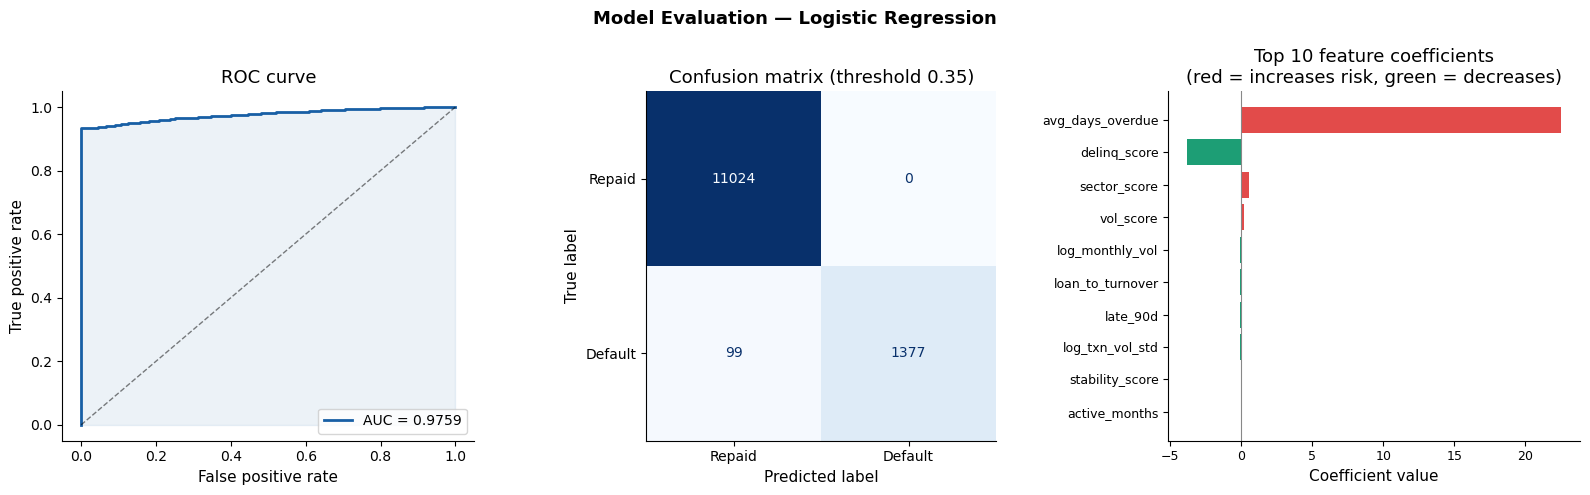


Model evaluation plots saved → model_evaluation.png


In [22]:
print("\n" + "=" * 60)
print("PHASE 5 — Logistic Regression Model")
print("=" * 60)
 
# ── 5.1 Define feature set ────────────────────────────────────────────────────
FEATURES = [
    'repay_risk',          # engineered
    'vol_score',           # engineered
    'delinq_score',        # engineered
    'stability_score',     # engineered
    'sector_score',        # engineered
    'log_monthly_vol',     # raw signal (log-transformed)
    'log_loan_amount',     # raw signal (log-transformed)
    'log_txn_vol_std',     # raw signal (log-transformed)
    'active_months',       # raw signal
    'avg_days_overdue',    # raw signal
    'late_90d',            # raw signal
    'gst_registered',      # binary
    'loan_to_turnover',    # derived ratio
]
 
TARGET = 'delinquency_flag'
 
X = df_feat[FEATURES].fillna(0)
y = df_feat[TARGET]
 
print(f"\nFeature matrix : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target balance : {y.mean()*100:.2f}% positive (defaults)")
 
# ── 5.2 Train / Test split (stratified) ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y          # preserves class ratio in both splits
)
print(f"\nTrain : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")
 
# ── 5.3 Scale features ────────────────────────────────────────────────────────
# StandardScaler: mean=0, std=1 — required for logistic regression
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)   # fit on train only
X_test_sc   = scaler.transform(X_test)        # apply same scale to test
 
# ── 5.4 Train logistic regression ────────────────────────────────────────────
# class_weight='balanced' auto-weights minority class (defaults)
# This is the correct approach for imbalanced credit data
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)
model.fit(X_train_sc, y_train)
print("\nModel trained.")
 
# ── 5.5 Cross-validation (5-fold stratified) ─────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
print(f"\n5-Fold CV AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold      : {[round(s,4) for s in cv_scores]}")
 
# ── 5.6 Test set evaluation ───────────────────────────────────────────────────
y_pred_proba  = model.predict_proba(X_test_sc)[:, 1]
y_pred_thresh = (y_pred_proba >= 0.35).astype(int)   # 0.35 threshold maximises recall on defaults
 
auc = roc_auc_score(y_test, y_pred_proba)
 
print(f"\n{'='*40}")
print(f"TEST SET RESULTS")
print(f"{'='*40}")
print(f"AUC-ROC        : {auc:.4f}")
print(f"\nClassification report (threshold = 0.35):")
print(classification_report(y_test, y_pred_thresh, target_names=['Repaid', 'Default']))
 
# ── 5.7 Feature importance (coefficients) ─────────────────────────────────────
coef_df = (
    pd.DataFrame({'feature': FEATURES, 'coefficient': model.coef_[0]})
    .assign(abs_coef=lambda x: x['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
    .reset_index(drop=True)
)
print("\nFeature importance (logistic regression coefficients):")
print(coef_df[['feature', 'coefficient']].to_string(index=False))
 
# ── 5.8 Evaluation plots ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('Model Evaluation — Logistic Regression', fontsize=13, fontweight='bold')
 
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes2[0].plot(fpr, tpr, color='#185FA5', linewidth=2, label=f'AUC = {auc:.4f}')
axes2[0].plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5)
axes2[0].fill_between(fpr, tpr, alpha=0.08, color='#185FA5')
axes2[0].set_xlabel('False positive rate')
axes2[0].set_ylabel('True positive rate')
axes2[0].set_title('ROC curve')
axes2[0].legend(loc='lower right')
 
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_thresh)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Repaid', 'Default'])
disp.plot(ax=axes2[1], colorbar=False, cmap='Blues')
axes2[1].set_title('Confusion matrix (threshold 0.35)')
 
# Feature Importance Bar
top10 = coef_df.head(10)
bar_colors = ['#E24B4A' if c > 0 else '#1D9E75' for c in top10['coefficient']]
axes2[2].barh(top10['feature'][::-1], top10['coefficient'][::-1], color=bar_colors[::-1])
axes2[2].axvline(0, color='#888', linewidth=0.8)
axes2[2].set_xlabel('Coefficient value')
axes2[2].set_title('Top 10 feature coefficients\n(red = increases risk, green = decreases)')
axes2[2].tick_params(labelsize=9)
 
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nModel evaluation plots saved → model_evaluation.png")

<h3>SCORE ALL BORROWERS & WRITE BACK TO MySQL</h3>

In [23]:
print("\n" + "=" * 60)
print("PHASE 6 — Score all borrowers & write back to MySQL")
print("=" * 60)
 
# Score the full dataset (not just test set)
X_all_sc = scaler.transform(df_feat[FEATURES].fillna(0))
df_feat['default_probability'] = model.predict_proba(X_all_sc)[:, 1]
df_feat['ml_decision'] = np.where(
    df_feat['default_probability'] >= 0.35, 'HIGH_RISK', 'LOW_RISK'
)
 
# Final output columns for the scored table
output_cols = [
    'msme_id', 'business_name', 'category', 'state',
    'loan_id', 'loan_amount', 'loan_status', 'delinquency_flag',
    'avg_monthly_vol', 'txn_volatility', 'repayment_ratio',
    'avg_days_overdue', 'business_age_yrs',
    'risk_score', 'risk_tier', 'decision',
    'default_probability', 'ml_decision'
]
 
df_scored = df_feat[output_cols].copy()
df_scored['risk_tier'] = df_scored['risk_tier'].astype(str)
 
# Write scored results back to MySQL
df_scored.to_sql(
    'msme_scored',
    engine,
    if_exists='replace',
    index=False,
    chunksize=1000,
    method='multi'
)
print(f"\nScored table written to MySQL → msme_scored ({len(df_scored):,} rows)")



PHASE 6 — Score all borrowers & write back to MySQL

Scored table written to MySQL → msme_scored (50,000 rows)


In [25]:
# ── Summary stats on scored table ─────────────────────────────────────────────
print("\n--- FINAL PORTFOLIO SUMMARY ---")
print(f"Total borrowers scored    : {len(df_scored):,}")
print(f"Overall default rate      : {df_scored['delinquency_flag'].mean()*100:.2f}%")
print(f"Avg risk score            : {df_scored['risk_score'].mean():.1f} / 100")
print(f"Auto-reject rate          : {(df_scored['decision']=='AUTO_REJECT').mean()*100:.1f}%")
print(f"Manual review rate        : {(df_scored['decision']=='MANUAL_REVIEW').mean()*100:.1f}%")
print(f"Auto-approve rate         : {(df_scored['decision']=='AUTO_APPROVE').mean()*100:.1f}%")
print(f"Model AUC on test set     : {auc:.4f}")
 
print("\n✓ Pipeline complete.")
print("  Outputs:")
print("  → eda_dashboard.png    (EDA charts — import into Power BI)")
print("  → model_evaluation.png (ROC curve, confusion matrix, feature importance)")
print("  → MySQL table: msme_scored (connect Power BI directly to this table)")


--- FINAL PORTFOLIO SUMMARY ---
Total borrowers scored    : 50,000
Overall default rate      : 11.81%
Avg risk score            : 21.1 / 100
Auto-reject rate          : 47.2%
Manual review rate        : 1.2%
Auto-approve rate         : 51.7%
Model AUC on test set     : 0.9759

✓ Pipeline complete.
  Outputs:
  → eda_dashboard.png    (EDA charts — import into Power BI)
  → model_evaluation.png (ROC curve, confusion matrix, feature importance)
  → MySQL table: msme_scored (connect Power BI directly to this table)


In [ ]:
df_scored.to_csv('msme-credit-risk-scoring/data/msme_scored.csv', index=False)